# Updating attributes


## Scraps

I matched up ASOSAWOS stations from the merge station list with the lat lons of the stations in the list that Mithra shared.

In [ ]:
# load station list
station_list = pd.read_csv(stations_csv_path)
station_list = station_list[station_list['network']=='ASOSAWOS']

In [ ]:
# convert to geodataframe
asos_stns = gpd.GeoDataFrame(
    station_list,
    geometry=gpd.points_from_xy(
        station_list.longitude, station_list.latitude, crs="EPSG:4326"
    ),
)

In [ ]:
# load in list that Mithra shared (stored in separate repo)
lookup_table = pd.read_csv("../../skillshare_demo/lookup_table.csv")

In [ ]:
# convert it to a geodataframe
lookup_table = gpd.GeoDataFrame(
    lookup_table,
    geometry=gpd.points_from_xy(
        lookup_table.longitude, lookup_table.latitude, crs="EPSG:4326"
    ),
)

In [ ]:
# and filter for ease of use later
lookup_table = lookup_table[
    ["Airport Code", "City", "latitude", "longitude",'geometry']
]

In [ ]:
# establish buffers around the point geometries, as they will not be exact matches

# define the error margin (buffer distance)
error_margin = 0.1  # Adjust this value as needed

# apply buffer to account for the error margin
lookup_table_buffered = lookup_table.copy()
lookup_table_buffered["geometry"] = lookup_table.geometry.buffer(error_margin)

asos_stns_buffered = asos_stns.copy()
asos_stns_buffered["geometry"] = asos_stns.geometry.buffer(error_margin)

/tmp/ipykernel_31410/1684058703.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lookup_table_buffered["geometry"] = lookup_table.geometry.buffer(error_margin)
/tmp/ipykernel_31410/1684058703.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  asos_stns_buffered["geometry"] = asos_stns.geometry.buffer(error_margin)


In [ ]:
# perform the overlay operation (e.g., intersection)
matchup_buffered = gpd.overlay(asos_stns_buffered, lookup_table_buffered, how="intersection")

In [ ]:
# clean things up 
matchup_buffered = matchup_buffered[["era-id", "longitude_1", "latitude_1","longitude_2", "latitude_2",'Airport Code','City']]

Now go through each city in the list (which I added manually before starting this process) and check which HDP station is a match. I added the station ID to a copy of the list in my drive along the way.

In [ ]:
matchup_buffered[matchup_buffered["City"] == "San Jose"]

,era-id,longitude_1,latitude_1,longitude_2,latitude_2,Airport Code,City
19,ASOSAWOS_72494523293,-121.924,37.359,-121.82,37.33,KRHV,San Jose


I then downloaded a cleaned version of the table and load it in here (again, stored in a separate repo).

In [ ]:
matchup_table = pd.read_csv("../../skillshare_demo/final_lookup_table.csv")

And generated two dictionaries from it - one for airport codes, another for airport cities

In [ ]:
code_dict = pd.Series(matchup_table["HDP station"].values, index=matchup_table["Airport Code"]).to_dict()

In [ ]:
city_dict = pd.Series(
    matchup_table["HDP station"].values, index=matchup_table["City"]
).to_dict()

## Environment set-up

In [ ]:
import datetime
import boto3
import geopandas as gpd
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from io import BytesIO, StringIO

from merge_log_config import logger

# Silence warnings
import warnings
from shapely.errors import ShapelyDeprecationWarning

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings(
    "ignore", category=ShapelyDeprecationWarning
)  # Warning is raised when creating Point object from coords. Can't figure out why.

plt.rcParams["figure.dpi"] = 300

In [6]:
# AWS credentials
s3 = boto3.resource("s3")
s3_cl = boto3.client("s3")

## AWS buckets
bucket = "wecc-historical-wx"
qaqcdir = "3_qaqc_wx/"
mergedir = "4_merge_wx/"

## Testing

In [ ]:
def merge_ds_to_df(ds):
    """Converts xarray ds for a station to pandas df in the format needed for processing.

    Parameters
    ----------
    ds: xr.Dataset
        Data object with information about each network and station
    verbose: boolean
        Flag as to whether to print runtime statements to terminal. Default is False. Set in ALLNETWORKS_merge.py run.

    Returns
    -------
    df: pd.DataFrame
        Table object with information about each network and station
    MultiIndex: pd.DataFrame (I think)
        Original multi-index of station and time, to be used on conversion back to ds
    attrs:
        Save ds attributes to inherent to the final merged file
    var_attrs:
        Save variable attributes to inherent to the final merged file
    """

    # Save attributes to inherent them to the final merged file
    attrs = ds.attrs
    var_attrs = {var: ds[var].attrs for var in list(ds.data_vars.keys())}

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        df = ds.to_dataframe()

    # Save instrumentation heights
    if "anemometer_height_m" not in df.columns:
        try:
            df["anemometer_height_m"] = (
                np.ones(ds["time"].shape) * ds.anemometer_height_m
            )
        except:
            df["anemometer_height_m"] = np.ones(len(df)) * np.nan
        finally:
            pass
    if "thermometer_height_m" not in df.columns:
        try:
            df["thermometer_height_m"] = (
                np.ones(ds["time"].shape) * ds.thermometer_height_m
            )
        except:
            df["thermometer_height_m"] = np.ones(len(df)) * np.nan
        finally:
            pass

    # De-duplicate time axis
    df = df[~df.index.duplicated()].sort_index()

    # Save station/time multiindex
    MultiIndex = df.index
    station = df.index.get_level_values(0)
    df["station"] = station

    # Station pd.Series to str
    station = station.unique().values[0]

    # Convert time/station index to columns and reset index
    df = df.droplevel(0).reset_index()

    return df, MultiIndex, attrs, var_attrs

In [ ]:
url = "s3://wecc-historical-wx/3_qaqc_wx/VALLEYWATER/VALLEYWATER_6001.zarr"  
# url = "s3://wecc-historical-wx/3_qaqc_wx/ASOSAWOS/ASOSAWOS_69007093217.zarr"
ds = xr.open_zarr(url)
# df = ds.to_dataframe()

In [56]:
df, MultiIndex, attrs, var_attrs = merge_ds_to_df(ds)

In [57]:
var_attrs

{'anemometer_height_m': {},
 'elevation': {'ancillary_variables': 'elevation_eraqc',
  'long_name': 'station_elevation',
  'positive': 'up',
  'standard_name': 'height_above_mean_sea_level',
  'units': 'meter'},
 'elevation_eraqc': {},
 'lat': {},
 'lon': {},
 'pr_15min': {'ancillary_variables': 'pr_15min_eraqc',
  'comment': 'Precipitation accumulated in previous 15 minutes.',
  'long_name': '15_minute_precipitation_amount',
  'units': 'mm/15min'},
 'pr_15min_eraqc': {},
 'raw_qc': {},
 'thermometer_height_m': {}}

In [58]:
sub_hourly_vars = [i for i in df.columns if "min" in i and "qc" not in i]

In [59]:
for var in sub_hourly_vars:
    var_attrs[var]['standardization'] = '{} has been standardized to an hourly timestep, but will retain its original name'.format(var)

In [60]:
var_attrs

{'anemometer_height_m': {},
 'elevation': {'ancillary_variables': 'elevation_eraqc',
  'long_name': 'station_elevation',
  'positive': 'up',
  'standard_name': 'height_above_mean_sea_level',
  'units': 'meter'},
 'elevation_eraqc': {},
 'lat': {},
 'lon': {},
 'pr_15min': {'ancillary_variables': 'pr_15min_eraqc',
  'comment': 'Precipitation accumulated in previous 15 minutes.',
  'long_name': '15_minute_precipitation_amount',
  'units': 'mm/15min',
  'standardization': 'pr_15min has been standardized to an hourly timestep, but will retain its original name'},
 'pr_15min_eraqc': {},
 'raw_qc': {},
 'thermometer_height_m': {}}

In [ ]:
def merge_hourly_standardization_test(
    df: pd.DataFrame, var_attrs: dict, logger: logging.Logger
) -> tuple[pd.DataFrame, dict]:
    """Resamples meteorological variables to hourly timestep according to standard conventions.

    Parameters
    -----------
    df : pd.DataFrame
        station dataset converted to dataframe through QAQC pipeline
    var_attrs: library
        attributes for sub-hourly variables
    logger : logging.Logger
        Logger instance for recording messages during processing.

    Returns
    -------
    df : pd.DataFrame | None
        returns a dataframe with all columns resampled to one hour (column name retained)
    var_attrs : dict | None
        returns variable attributes dictionary updated to note that sub-hourly variables are now hourly

    Notes
    -----
    Rules:
    1. Top of the hour: take the first value in each hour. Standard convention for temperature, dewpoint, wind speed, direction, relative humidity, air pressure.
    2. Summation across the hour: sum observations within each hour. Standard convention for precipitation and solar radiation.
    3. Constant across the hour: take the first value in each hour. This applied to variables that do not change.
    """

    logger.info(f"Running merge_hourly_standardization")

    # Variables that remain constant within each hour
    constant_vars = [
        "time",
        "station",
        "lat",
        "lon",
        "elevation",
        "anemometer_height_m",
        "thermometer_height_m",
    ]

    # Aggregation across hour variables, standard meteorological convention: precipitation and solar radiation
    sum_vars = [
        "time",
        "pr",
        "pr_localmid",
        "pr_24h",
        "pr_1h",
        "pr_15min",
        "pr_5min",
        "rsds",
    ]

    # Top of the hour variables, standard meteorological convention: temperature, dewpoint temperature, pressure, humidity, winds
    instant_vars = [
        "time",
        "tas",
        "tdps",
        "tdps_derived",
        "ps",
        "psl",
        "ps_altimeter",
        "ps_derived",
        "hurs",
        "sfcWind",
        "sfcWind_dir",
    ]

    # QAQC flags, which remain constants within each hour
    vars_to_remove = ["qc", "eraqc", "duration", "method", "flag", "depth", "process"]
    qaqc_vars = [
        var for var in df.columns if any(True for item in vars_to_remove if item in var)
    ]

    # All variables, necessary for producing columns with hourly counts for each variable
    # all_vars = constant_vars + sum_vars + instant_vars + qaqc_vars

    # Subset the dataframe according to rules
    constant_df = df[[col for col in constant_vars if col in df.columns]]

    qaqc_df = df[[col for col in qaqc_vars if col in df.columns if col != "time"]]
    qaqc_df = qaqc_df.astype(str)
    qaqc_df.insert(0, "time", df["time"])

    sum_df = df[[col for col in sum_vars if col in df.columns]]

    print(df.columns)

    instant_df = df[[col for col in instant_vars if col in df.columns]]

    try:
        # If station does not report any variable, bypass
        if len(df.columns) == 0:
            logger.info("Empty dataset - bypassing hourly aggregation")
            return df, var_attrs
        else:
            result_list = []

            # Performing hourly aggregation, only if subset contains more than one (ie more than the 'time' time) column
            # This is to account for input dataframes that do not contain ALL subsets of variables defined above - just a subset of them.
            if len(constant_df.columns) > 1:
                constant_result = constant_df.resample("1h", on="time").first()
                result_list.append(constant_result)

            if len(instant_df.columns) > 1:
                instant_result = instant_df.resample("1h", on="time").first()
                result_list.append(instant_result)

            if len(sum_df.columns) > 1:
                sum_result = sum_df.resample("1h", on="time").apply(
                    lambda x: np.nan if x.isna().all() else x.sum(skipna=True)
                )
                result_list.append(sum_result)

            if len(qaqc_df.columns) > 1:
                qaqc_result = qaqc_df.resample("1h", on="time").apply(
                    lambda x: ",".join(x.unique())
                )  # adding unique flags
                result_list.append(qaqc_result)

            # Aggregate and output reduced dataframe - this merges all dataframes defined
            result = reduce(
                lambda left, right: pd.merge(left, right, on=["time"], how="outer"),
                result_list,
            )

            # Update attributes for sub-hourly variables
            sub_hourly_vars = [i for i in df.columns if "min" in i and "qc" not in i]
            for var in sub_hourly_vars:
                var_attrs[var]["standardization"] = (
                    "{} has been standardized to an hourly timestep, but will retain its original name".format(
                        var
                    )
                )
            logger.info("Pass merge_hourly_standardization")

            return result, var_attrs

    except Exception as e:
        logger.error(f"hourly_standardization failed with Exception: {e}")
        raise e

In [ ]:
## Identify vars that can be derived
def merge_derive_missing_vars(
    df: pd.DataFrame, var_attrs: dict
) -> tuple[pd.DataFrame, dict]:
    """
    Identifies if any variables can be derived with other input variables.
    If success, variable is derived in the correct unit, attribtues are updated,
    and any flags from the input variables are synergistically flagged.
    If failure, variable is not derived.

    Parameters
    ----------
    df : pd.DataFrame
        input dataframe
    var_attrs: dict
        updated variable attributes

    Returns
    -------
    df_flag : pd.DataFrame
        dataframe with newly added derived variable
    """
    print("Running merge_derive_missing_vars...")  # conver to logger when ready

    # vars that can be derived
    derive_vars = ["tdps", "hurs", "tas"]  # only tdps, not tdps_derived

    # first check if station has any vars that can be derived
    for item in derive_vars:
        if item in df.columns:
            print(
                f"{item} is present in station, no derivation necessary."
            )  # convert to logger when set-up
            continue

        else:  # var is missing
            if item == "hurs" and _input_var_check(df, var1="tas", var2="tdps") == True:
                print(f"Calculating {item}_derived...")  # convert to logger when set-up
                df["hurs_derived"] = _calc_relhumid(df["tas"], df["tdps"])
                # synergistic flag check
                df = derive_synergistic_flag(df, "hurs_derived", "tas", "tdps")
                # add derived variable attribute
                var_attrs["hurs_derived"] = (
                    "Variable derived from tas and tdps with merge_derive_missing()."
                )

            elif (
                item == "hurs"
                and _input_var_check(df, var1="tas", var2="tdps_derived") == True
            ):
                print(
                    f"Calculating {item}_derived ..."
                )  # convert to logger when set-up
                df["hurs_derived"] = _calc_relhumid(df["tas"], df["tdps_derived"])
                # synergistic flag check
                df = derive_synergistic_flag(df, "hurs_derived", "tas", "tdps_derived")
                # add derived variable attribute
                var_attrs["hurs_derived"] = (
                    "Variable derived from tas and tdps_derived with merge_derive_missing()."
                )

            elif (
                item == "tas" and _input_var_check(df, var1="hurs", var2="tdps") == True
            ):
                print(f"Calculating {item}_derived...")  # convert to logger when set-up
                df["tas_derived"] = _calc_airtemp(df["hurs"], df["tdps"])
                # synergistic flag check
                df = derive_synergistic_flag(df, "tas_derived", "hurs", "tdps")
                # add derived variable attribute
                var_attrs["tas_derived"] = (
                    "Variable derived from hurs and tdps with merge_derive_missing()."
                )

            elif (
                item == "tas"
                and _input_var_check(df, var1="hurs", var2="tdps_derived") == True
            ):
                print(
                    f"Calculating {item}_derived ...."
                )  # convert to logger when set-up
                df["tas_derived"] = _calc_airtemp(df["hurs"], df["tdps_derived"])
                # synergistic flag check
                df = derive_synergistic_flag(df, "tas_derived", "tas", "tdps_derived")
                # add derived variable attribute
                var_attrs["tas_derived"] = (
                    "Variable derived from hurs and tdps_derived with merge_derive_missing()."
                )

            # check if required inputs are available
            elif (
                item == "tdps" and _input_var_check(df, var1="tas", var2="hurs") == True
            ):
                if "tdps_derived" not in df.columns:
                    print(
                        f"Calculating {item}_derived..."
                    )  # convert to logger when set-up
                    df["tdps_derived"] = _calc_dewpointtemp(df["tas"], df["hurs"])
                    # synergistic flag check
                    df = derive_synergistic_flag(df, "tdps_derived", "tas", "hurs")
                    # add derived variable attribute
                    var_attrs["tdps_derived"] = (
                        "Variable derived from tas and hurs with merge_derive_missing()."
                    )

                else:
                    print(
                        "tdps_derived is present in station, no derivation necessary."
                    )
            else:
                print(
                    f"{item} is missing the required input variables. {item}_derived not calculated."
                )  # convert to logger when set-up

    return df, var_attrs

## Visualization

In [ ]:
fig, ax = plt.subplots()

df.plot(
    ax=ax,
    x="time",
    y="pr",
    marker="o",
    ms=7,
    lw=0,
    mfc="none",
    color="C3",
    label="pr",
)

## Comparison Map

In [ ]:
# load california state boundary
state_boundaries = gpd.read_file("s3://wecc-historical-wx/0_maps/tl_2021_us_state/")
ca_boundary = state_boundaries[state_boundaries["NAME"] == ("California")]
ca_boundary = ca_boundary.to_crs(stns_gdf.crs)

In [ ]:
# filter station list to those located in California
ca_stations = stns_gdf.clip(ca_boundary)

In [ ]:
# grab stations that only have solar radiation or wind
# rsds, sfcWind, sfcWind_dir
ca_stations['contains_target_vars'] = (~ca_stations["sfcwind_nobs"] == 0) | (~ca_stations["sfcwind_dir_nobs"] == 0) | (
    ~ca_stations["rsds_nobs"] == 0
)

/home/machuca/miniconda3/envs/hist-obs/lib/python3.10/site-packages/geopandas/geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
ca_stations

,Unnamed: 0,era-id,latitude,longitude,elevation,start-date,end-date,pulled,time_checked,network,...,sfcwind_nobs,sfcwind_dir_nobs,rsds_nobs,total_nobs,qaqc,time_qaqc,merged,time_merge,geometry,contains_target_vars
12204,12204,OtherISD_69015099999,34.300000,-116.167000,626.0000,1989-11-15 00:00:00+00:00,1989-12-29 00:00:00+00:00,Y,2023-03-22 00:20:28+00:00,OtherISD,...,415,291,0,419,Y,2025-05-02 06:11:19+00:00,Y,2025-06-12 22:20:32+00:00,POINT (-116.16700 34.30000),False
690,690,CIMIS_221,34.513611,-115.510556,797.0000,2010-11-01 00:00:00+00:00,2025-06-23 13:51:08.212066+00:00,NaN,NaN,CIMIS,...,87791,87792,87769,93471,Y,2025-05-01 20:04:46+00:00,Y,2025-06-12 19:06:42+00:00,POINT (-115.51056 34.51361),False
12507,12507,RAWS_TS801,34.565000,-116.208333,2865.0000,2019-11-12 23:56:00+00:00,2022-08-22 12:53:00+00:00,Y,2023-03-24 14:12:34+00:00,RAWS,...,7463,7351,0,7463,Y,2025-05-02 07:10:02+00:00,Y,2025-06-12 23:16:39+00:00,POINT (-116.20833 34.56500),False
14722,14722,SCAN_2185,34.672350,-115.166930,2644.0000,2011-11-19 00:00:00+00:00,2100-01-01 00:00:00+00:00,Y,2023-03-21 21:41:49+00:00,SCAN,...,0,0,0,94476,Y,2025-05-02 06:21:16+00:00,Y,2025-06-12 23:25:38+00:00,POINT (-115.16693 34.67235),False
440,440,ASOSAWOS_72380523179,34.768000,-114.618000,270.6624,1977-02-17 00:00:00+00:00,2022-12-31 00:00:00+00:00,Y,2023-01-09 16:28:28+00:00,ASOSAWOS,...,255933,206806,0,327456,Y,2025-05-01 19:39:46+00:00,Y,2025-06-12 18:36:51+00:00,POINT (-114.61800 34.76800),False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1923,1923,CWOP_E3157,35.769670,-117.375330,1670.0000,2013-07-24 00:00:00+00:00,2018-03-10 16:31:00+00:00,Y,2023-04-06 18:02:34+00:00,CWOP,...,257413,123116,22,262019,Y,2025-05-01 23:55:08+00:00,Y,2025-06-12 20:25:54+00:00,POINT (-117.37533 35.76967),False
14064,14064,RAWS_INTC1,36.120278,-117.087778,6880.0000,1999-12-02 00:00:00+00:00,2015-07-16 18:50:00+00:00,Y,2023-03-24 14:12:34+00:00,RAWS,...,131952,123728,130455,132025,Y,2025-05-02 06:55:30+00:00,Y,2025-06-12 22:51:19+00:00,POINT (-117.08778 36.12028),False
9743,9743,HADS_BWBC1,36.229440,-116.766940,-219.0000,2021-08-23 21:19:00+00:00,2023-01-16 16:00:00+00:00,Y,2023-03-23 19:49:23+00:00,HADS,...,7892,4810,0,8897,Y,2025-05-02 00:51:16+00:00,Y,2025-06-12 21:04:38+00:00,POINT (-116.76694 36.22944),False
9128,9128,HADS_DEVC1,36.462220,-116.863610,-193.0000,2013-03-16 00:00:00+00:00,2023-01-16 16:00:00+00:00,Y,2023-03-23 19:49:23+00:00,HADS,...,79877,74049,0,79923,Y,2025-05-02 00:56:50+00:00,Y,2025-06-12 21:17:42+00:00,POINT (-116.86361 36.46222),False


In [ ]:
def get_station_map(station_list: str, shapefile: str, IOU) -> None:
    """
    Generates and exports a map of station locations from the station list of the input phase.

    Parameters
    ----------
    phase: str
        the pipeline phase - "pull", "clean", "qaqc" or "merge"
    shapepath: string
        path to shapefile ofr 2021 US state borders

    Returns
    -------
    None

    """
    # if phase not in ["pull", "clean", "qaqc", "merge"]:
    #     print(f"invalid phase:{phase}")
    #     return None

    # ## Get station list
    # directory = phase_dict[phase]
    # station_list = pd.read_csv(
    #     f"s3://{BUCKET_NAME}/{directory}/all_network_stationlist_{phase}.csv"
    # )

    ## Get period

    # Format dates in datetime format (this gets lost in import).
    station_list["start-date"] = pd.to_datetime(station_list["start-date"], utc=True)
    station_list["end-date"] = pd.to_datetime(station_list["end-date"], utc=True)

    # Make a geodataframe.
    gdf = gpd.GeoDataFrame(
        station_list,
        geometry=gpd.points_from_xy(station_list.longitude, station_list.latitude),
    )
    gdf.set_crs(epsg=4326, inplace=True)  # Set CRS

    # Project data to match base tiles.
    gdf_wm = gdf.to_crs(epsg=3857)  # Web mercator

    # # Read in geometry of continental US.
    # us = gpd.read_file(shapepath)

    # Remove territories, AK, HI
    list = [IOU]
    shapefile = shapefile.to_crs(gdf.crs)
    shapefile = shapefile.loc[shapefile.ABR.isin(list) == True]

    # Use to clip stations
    shapefile = shapefile.to_crs(epsg=3857)
    gdf_us = gdf_wm.clip(shapefile)

    # Plot
    ax = gdf_us.plot(
        "network",
        figsize=(15, 15),
        alpha=1,
        markersize=3,
        legend=True,
        cmap="nipy_spectral",
    )
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
    ax.set_axis_off()

    # # Save to AWS
    # img_data = BytesIO()
    # plt.savefig(img_data, format="png")
    # img_data.seek(0)

    # bucket = s3.Bucket(BUCKET_NAME)
    # export_folder = phase_dict[phase]
    # export_key = f"{export_folder}/{phase}_station_map.png"
    # bucket.put_object(
    #     Body=img_data,
    #     ContentType="image/png",
    #     Key=export_key,
    # )

    return None

### Sample of logging stats

In [ ]:
logger.info("Running: succes_report_stats")

# identify _eraqc variables
eraqc_vars = [var for var in df.columns if "_eraqc" in var]

# number of total observations in station
logger.info("Total observations: {}".format(len(df)))

#

for var in eraqc_vars:
    # list of unique flags
    logger.info(
        "Flags set on {}: {}".format(var, df[var].unique()),
    )
    # % of observations flagged per variables
    logger.info(
        "Coverage of {} obs flagged: {} of {} obs ({}%)".format(
            var,
            len(df.loc[(df[var].isnull() == False)]),
            len(df),
            round((len(df.loc[(df[var].isnull() == False)]) / len(df)) * 100, 3),
        )
    )

In [ ]:
def flag_summary_hourly(df: pd.DataFrame):
    """
    Generates summary of flags set on all QAQC tests.
    Returns
    - list of unique flag values for each variable
    - % of total obs per variable that was flagged
    - total number of observations per variable
    - number of flagged observations per variable


    Parameters
    ----------
    df : pd.DataFrame
        station dataset converted to dataframe through QAQC pipeline

    Returns
    -------
    pd.dataFrame
    """

    logger.info("Running: succes_report_stats")

    # identify _eraqc variables
    eraqc_vars = [var for var in df.columns if "_eraqc" in var]

    # number of total observations in station
    logger.info("Total observations: {}".format(len(df)))

    for var in eraqc_vars:
        # number of total observations per variables
        logger.info()

        # list of unique flags
        logger.info(
            "Flags set on {}: {}".format(var, df[var].unique()),
        )

        # count of

        # % of observations flagged per variables
        logger.info(
            "Coverage of {} obs flagged: {} of {} obs ({}%)".format(
                var,
                len(df.loc[(df[var].isnull() == False)]),
                len(df),
                round((len(df.loc[(df[var].isnull() == False)]) / len(df)) * 100, 3),
            )
        )

## Download csv from AWS

In [ ]:
##### Import station list of target station
key = "2_clean_wx/{}/stationlist_{}_cleaned.csv".format(station,station)
bucket_name = "wecc-historical-wx"
list_import = s3_cl.get_object(
    Bucket=bucket,
    Key=key,
)
station_list = pd.read_csv(BytesIO(list_import["Body"].read()))


You don't need to do the above! 

In [ ]:
key = f"4_merge_wx/{network}/eraqc_counts/{station}_flag_counts_native_timestep.csv"
flag_counts_table = pd.read_csv(f"s3://wecc-historical-wx/{key}")

In [ ]:
key_1 = f"{merge_dir}/ASOSAWOS/eraqc_counts_native_timestep/ASOSAWOS_A0705300346_flag_counts_native_timestep.csv"
flag_table_1 = pd.read_csv(f"s3://wecc-historical-wx/{key_1}")
key_2 = f"{merge_dir}/ASOSAWOS/eraqc_counts_native_timestep/ASOSAWOS_72479694128_flag_counts_native_timestep.csv"
flag_table_2 = pd.read_csv(f"s3://wecc-historical-wx/{key_2}")



csv_s3_filepath = f"s3://wecc-historical-wx/4_merge_wx/test_strings.csv"
counts_final.to_csv(csv_s3_filepath, index=False)
key_test = f"{merge_dir}/test_strings.csv"
flag_table_test = pd.read_csv(f"s3://wecc-historical-wx/{key_test}")

## Export CSV to AWS

In [ ]:
csv_s3_filepath = f"s3://wecc-historical-wx/4_merge_wx/{network}/eraqc_counts/original_timestep_{station}.csv"  
flag_counts.to_csv(csv_s3_filepath, index=False)  

# see merge flag counts script


### slice all string entries in a column

In [ ]:
event_stns["start-date"] = event_stns["start-date"].str[:10]
event_stns["end-date"] = event_stns["end-date"].str[:10]

In [ ]:
# convert strings to datetime
event_stns["start-date"] = pd.to_datetime(event_stns["start-date"]).dt.date
event_stns["end-date"] = pd.to_datetime(event_stns["end-date"]).dt.date

## Load CSV from nearby repo

In [ ]:
flag_df = pd.read_csv("../data/era_qaqc_flag_meanings.csv")

## Download zarr from AWS

In [ ]:
url = "s3://wecc-historical-wx/3_qaqc_wx/VALLEYWATER/VALLEYWATER_6001.zarr"
# url = "s3://wecc-historical-wx/3_qaqc_wx/ASOSAWOS/ASOSAWOS_69007093217.zarr"
ds = xr.open_zarr(url)
# df = ds.to_dataframe()

"""
merge_eraqc_counts.py

Generate and exports CSVs with counts of unique QAQC flag values per variable, in native
and hourly timesteps. These counts are used to produce QAQC flag statistics for the QAQC success report.

Functions
---------
- eraqc_counts_native_timestep: QAQC flag counts in the original timestep
- eraqc_counts_hourly_timestep: QAQC flag counts in the hourly (post standardization) timestep

Intended Use
------------
Import into merge workflows to generate information for the QAQC success report.
"""

In [ ]:
    if event_to_eval == "santa_ana_wind_2021":
        counties_to_grab = [
            "Del Norte",
            "Humboldt",
            "Mendocino",
            "Sonoma",
            "Marin",
            "San Francisco",
            "Los Angeles",
            "Orange",
            "San Diego",
            "Ventura",
            "Santa Barbara",
            "Santa Cruz",
            "San Mateo",
            "Monterey",
            "San Luis Obispo",
        ]
    if event_to_eval == "santa_ana_wind_1988":
        counties_to_grab = [
            "Los Angeles",
            "Orange",
            "San Diego",
            "San Bernardino",
            "Riverside",
        ]


bits

In [ ]:
# take a sub sample of stations
sub_sample = find_other_events(
    event_stns, event_start_date, event_end_date, 14, 5, return_stn_ids=True
)

Subsetting station record for event duration with 14 day buffer...
5 stations selected for evaluation for comparison!
Stations selected for evaluation:
 ['CWOP_AS654', 'CWOP_C7603', 'ASOSAWOS_72290693112', 'OtherISD_74718603164', 'ASOSAWOS_72292703177']


In [ ]:
def id_flag(flag_to_id: int) -> str:
    """
    Identifies flag based on numerical value assigned for plotting.

    Parameters
    ----------
    flag_to_id : int
        specific flag to identify

    Returns
    -------
    fn_name : str
        name of QA/QC flag
    """

    flag_df = pd.read_csv("../data/era_qaqc_flag_meanings.csv")
    fn_name = flag_df.loc[flag_df["Flag_value"] == int(flag_to_id)][
        "QAQC_function"
    ].values[0]

    return fn_name

In [ ]:
def event_plot_multiple_stations(
    sample: list,
    var: str,
    event: str,
    alt_start_date: str | None = None,
    alt_end_date: str | None = None,
    dpi: int | None = None,
):
    """Produces timeseries of variables that have flags placed

    Parameters
    ----------
    df : pd.DataFrame
        stationlist
    var : str
        name of variable
    event : str
        name of case study event
    alt_start_date : str
        date of different event, must be in format "YYYY-MM-DD"
    alt_end_date : str
        date of different event, must be in format "YYYY-MM-DD"
    dpi : int
        figure resolution

    Returns
    -------
    None
    """

    fig, ax = plt.subplots(figsize=(10, 3))

    # plot all observations
    for i in sample.index:
        station = sample.loc[i,"era-id"]
        network = sample.loc[i,"network"]

        url = f"s3://{BUCKET_NAME}/{MERGE_DIR}/{network}/{station}.zarr"

        ds = xr.open_zarr(url)

        df = ds.to_dataframe()
        df = df.reset_index()

        mask = (df["time"] >= "2007-10-05") & (df["time"] <= "2007-11-30")
        df = df.loc[mask]

        df.plot(
            ax=ax,
            x="time",
            y=var,
            marker=".",
            ms=4,
            lw=1,
            color="k",
            alpha=0.5,
            label=station,
        )


        # plot any flags placed by QA/QC
        if len(df[var + "_eraqc"].dropna().unique()) != 0:
            # identify flagged data, can handle multiple flags
            for flag in df[var + "_eraqc"].dropna().unique():
                flag_name = id_flag(flag)
                flag_str = 100 * len(df.loc[df[var + "_eraqc"] == flag, var]) / len(df)
                flag_label = f"{flag_str:.3f}% of data flagged by {flag_name}"

                flagged_data = df[~df[var + "_eraqc"].isna()]
                flagged_data.plot(
                    x="time",
                    y=var,
                    ax=ax,
                    #marker="o",
                    ms=7,
                    lw=0,
                    mfc="none",
                    color = np.random.rand(3,), #color="C3",
                    label=flag_label,
                )

    # plot event timeline
    event_start, event_end = event_info(event, alt_start_date, alt_end_date)
    ax.axvspan(
        event_start, event_end, color="red", alpha=0.1, label="{}".format(event)
    )
    legend = ax.legend(loc="upper left", prop={"size": 5})

    # plot aesthetics
    ylab, units, miny, maxy = _plot_format_helper(var)
    plt.ylabel(f"{ylab} [{units}]")
    plt.xlabel("")
    stn = df["station"].unique()[0]
    plt.title(
        f"QA/QC event evaluation: {event}: {stn}",
        fontsize=10,
    )

    return None

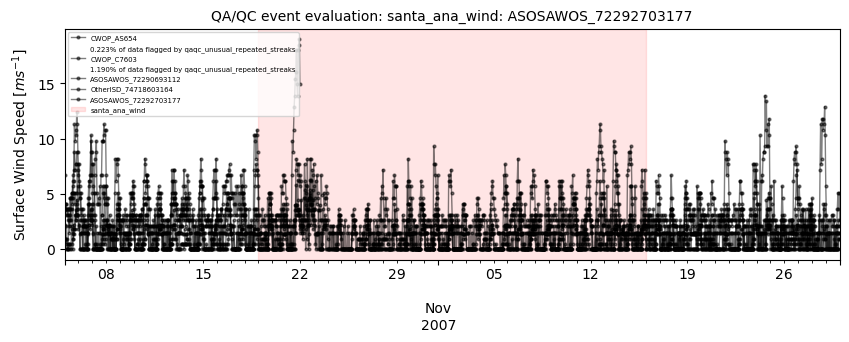

In [ ]:
event_plot_multiple_stations(sub_sample, 'sfcWind', 'santa_ana_wind')

In [ ]:
# Define a list of colors
custom_colors1 = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
custom_colors2 = ["#104D97", "#b5302b", "#e77431", "#503431", "#55a393"]
custom_colors3 = ["#104D97", "#ED254E", "#F9DC5C", "#71FFE4", "#A09BE7"]
custom_colors4 = ["#104D97", "#b5302b", "#e77431", "#503431", "#8DE3CF"]
custom_colors5 = ["#104D97", "#b5302b", "#A09BE7", "#503431", "#8DE3CF"]
colorblind10 = [
    "#006BA4",
    "#FF800E",
    "#5F9ED1",
    "#C85200",
    "#A2C8EC",
    "#FFBC79",
    "#A2C8EC",
]

# "#1C3C6E",
# "#A7D5B6",
# Create a ListedColormap
custom_cmap = ListedColormap(colorblind10)

## Scraps

I matched up ASOSAWOS stations from the merge station list with the lat lons of the stations in the list that Mithra shared.

In [ ]:
# load station list
station_list = pd.read_csv(stations_csv_path)
station_list = station_list[station_list['network']=='ASOSAWOS']

In [ ]:
# convert to geodataframe
asos_stns = gpd.GeoDataFrame(
    station_list,
    geometry=gpd.points_from_xy(
        station_list.longitude, station_list.latitude, crs="EPSG:4326"
    ),
)

In [ ]:
# load in list that Mithra shared (stored in separate repo)
lookup_table = pd.read_csv("../../skillshare_demo/lookup_table.csv")

In [ ]:
# convert it to a geodataframe
lookup_table = gpd.GeoDataFrame(
    lookup_table,
    geometry=gpd.points_from_xy(
        lookup_table.longitude, lookup_table.latitude, crs="EPSG:4326"
    ),
)

In [ ]:
# and filter for ease of use later
lookup_table = lookup_table[
    ["Airport Code", "City", "latitude", "longitude",'geometry']
]

In [ ]:
# establish buffers around the point geometries, as they will not be exact matches

# define the error margin (buffer distance)
error_margin = 0.1  # Adjust this value as needed

# apply buffer to account for the error margin
lookup_table_buffered = lookup_table.copy()
lookup_table_buffered["geometry"] = lookup_table.geometry.buffer(error_margin)

asos_stns_buffered = asos_stns.copy()
asos_stns_buffered["geometry"] = asos_stns.geometry.buffer(error_margin)

/tmp/ipykernel_31410/1684058703.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lookup_table_buffered["geometry"] = lookup_table.geometry.buffer(error_margin)
/tmp/ipykernel_31410/1684058703.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  asos_stns_buffered["geometry"] = asos_stns.geometry.buffer(error_margin)


In [ ]:
# perform the overlay operation (e.g., intersection)
matchup_buffered = gpd.overlay(asos_stns_buffered, lookup_table_buffered, how="intersection")

In [ ]:
# clean things up 
matchup_buffered = matchup_buffered[["era-id", "longitude_1", "latitude_1","longitude_2", "latitude_2",'Airport Code','City']]

Now go through each city in the list (which I added manually before starting this process) and check which HDP station is a match. I added the station ID to a copy of the list in my drive along the way.

In [ ]:
matchup_buffered[matchup_buffered["City"] == "San Jose"]

,era-id,longitude_1,latitude_1,longitude_2,latitude_2,Airport Code,City
19,ASOSAWOS_72494523293,-121.924,37.359,-121.82,37.33,KRHV,San Jose


I then downloaded a cleaned version of the table and load it in here (again, stored in a separate repo).

In [ ]:
matchup_table = pd.read_csv("../../skillshare_demo/final_lookup_table.csv")

And generated two dictionaries from it - one for airport codes, another for airport cities

In [ ]:
code_dict = pd.Series(matchup_table["HDP station"].values, index=matchup_table["Airport Code"]).to_dict()

In [ ]:
city_dict = pd.Series(
    matchup_table["HDP station"].values, index=matchup_table["City"]
).to_dict()